# Which NFL positions are worth paying for?

**Question:** Over 2013–2025, does the share of a team's salary cap spent on a position predict winning, and does it matter more at some positions than others? Do starters and bench players behave differently?

**Data** (all free, via `nflreadpy`): Over the Cap per-player cap hits, PFR snap counts, game results. Built by `src/build_data.py`.

**Key definitions**
- *Cap share* = a position group's cap hits ÷ the team's total tracked cap hits that season (so it is comparable across years as the cap grows).
- *Starter* = top-N players at the position by snaps (QB1, RB1, WR3, TE1, OL5, DL2, EDGE2, LB2, CB3, S2 = 11 offense / 11 defense). Everyone else, including injured players with 0 snaps, is *bench*.
- *Success* = regular-season point differential per game (less noisy than win %); win % used as a check.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

ts = pd.read_parquet("data/team_season.parquet")
ps = pd.read_parquet("data/player_season.parquet")
POS = ["QB", "RB", "WR", "TE", "OL", "DL", "EDGE", "LB", "CB", "S"]

# work in percentage points of cap so coefficients read as "per +1 point of cap share"
for p in POS:
    ts[f"{p}_st"] = ts[f"{p}_starter_share"] * 100
    ts[f"{p}_bn"] = ts[f"{p}_bench_share"] * 100
ts["ST_pct"] = ts["ST_all_share"] * 100
ts["bench_all"] = ts[[f"{p}_bn" for p in POS]].sum(axis=1)

def fit(formula, data=ts):
    # season fixed effects absorb league-wide year effects; SEs clustered by team
    return smf.ols(formula + " + C(season)", data).fit(cov_type="cluster", cov_kwds={"groups": data["team"]})

print(f"{len(ts)} team-seasons, {ts.season.min()}-{ts.season.max()}, {ts.team.nunique()} teams")
ts[["tracked_cap_m", "win_pct", "pt_diff_pg"]].describe().T

416 team-seasons, 2013-2025, 32 teams


,count,mean,std,min,25%,50%,75%,max
tracked_cap_m,416.000,159.657,37.066,65.529,129.758,158.513,181.921,270.883
win_pct,416.000,0.500,0.191,0.000,0.375,0.500,0.647,0.938
pt_diff_pg,416.000,0.002,6.070,-13.375,-4.500,-0.235,4.507,15.562


## 1. Where does the money go?

OL is the biggest line item (about 19% of the cap, 13% on the five starters alone). QB, WR, EDGE, DL and CB each take 10–11%. RB and TE are the cheapest groups. QB spend is the most uneven across teams, ranging from about 1% of cap (rookie deals) to 16%+ (franchise contracts).

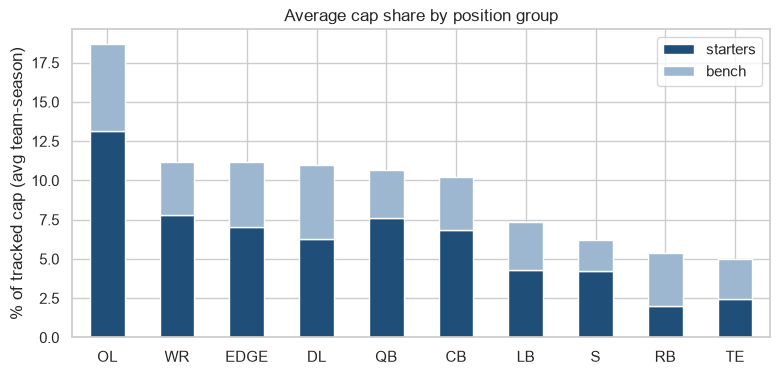

,starters,bench,total
OL,13.100,5.500,18.700
WR,7.800,3.400,11.200
EDGE,7.100,4.100,11.200
DL,6.200,4.800,11.000
QB,7.600,3.100,10.700
CB,6.900,3.400,10.200
LB,4.300,3.000,7.400
S,4.200,2.000,6.200
RB,2.000,3.400,5.400
TE,2.400,2.600,5.000


In [2]:
mix = pd.DataFrame({"starters": [ts[f"{p}_starter_share"].mean() for p in POS],
                    "bench": [ts[f"{p}_bench_share"].mean() for p in POS]}, index=POS) * 100
mix["total"] = mix.sum(axis=1)
mix = mix.sort_values("total", ascending=False)
ax = mix[["starters", "bench"]].plot.bar(stacked=True, figsize=(9, 4), color=["#1f4e79", "#9db7d1"])
ax.set(ylabel="% of tracked cap (avg team-season)", title="Average cap share by position group"); plt.xticks(rotation=0)
plt.show(); mix.round(1)

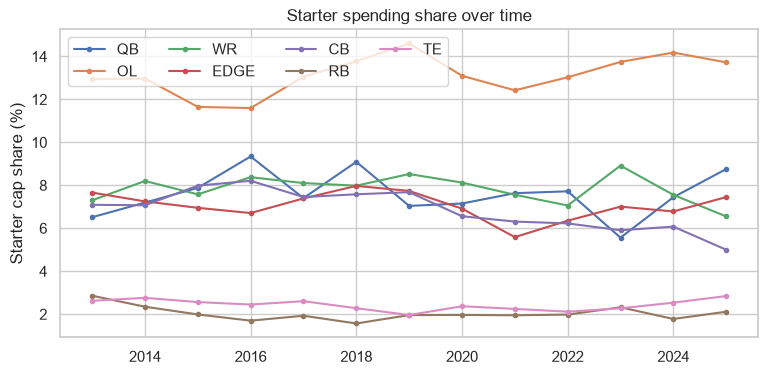

In [3]:
trend = ts.groupby("season")[[f"{p}_st" for p in POS]].mean()
fig, ax = plt.subplots(figsize=(9, 4))
for p in ["QB", "OL", "WR", "EDGE", "CB", "RB", "TE"]:
    ax.plot(trend.index, trend[f"{p}_st"], marker="o", ms=3, label=p)
ax.set(ylabel="Starter cap share (%)", title="Starter spending share over time"); ax.legend(ncol=4); plt.show()

## 2. Which positions' starters matter most? (all positions, one model)

**How to read this:** the baseline is bench/depth spending, so most coefficients are positive almost by construction (starters should beat depth). What matters is the *ranking and the uncertainty*. 1 point of cap share is roughly $1.6M for an average team.

- **QB stands out most reliably:** about +0.31 pts/game per point of cap share, and the interval is tight.
- **TE has the biggest coefficient (+0.44) but a very wide interval.** TE is only about 2% of the cap, so a few teams with elite TEs drive this. Treat it as a hint, not a finding.
- **EDGE, CB and OL** show modest, statistically significant effects (about +0.15 to +0.19).
- **S, DL, LB, RB and WR** are not distinguishable from zero.

The model explains only ~10% of the variance in point differential. Cap allocation is one small piece of what decides seasons.

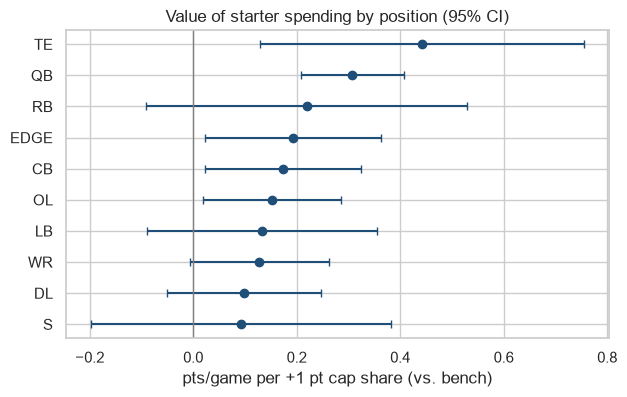

R² = 0.10, n = 416


,coef,lo,hi,p
S,0.092,-0.198,0.382,0.533
DL,0.098,-0.051,0.247,0.199
WR,0.128,-0.007,0.262,0.063
LB,0.133,-0.090,0.356,0.243
OL,0.152,0.018,0.285,0.026
CB,0.173,0.022,0.324,0.024
EDGE,0.193,0.022,0.364,0.027
RB,0.219,-0.092,0.530,0.167
QB,0.307,0.207,0.407,0.000
TE,0.442,0.129,0.755,0.006


In [4]:
# bench spending is the reference group: each coefficient = effect on point diff/game of moving
# +1 point of cap share from bench depth into that position's starters
m_joint = fit("pt_diff_pg ~ " + " + ".join(f"{p}_st" for p in POS) + " + ST_pct")
res = pd.DataFrame({"coef": m_joint.params, "lo": m_joint.conf_int()[0], "hi": m_joint.conf_int()[1],
                    "p": m_joint.pvalues}).loc[[f"{p}_st" for p in POS]]
res.index = POS; res = res.sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(res.coef, range(len(res)), xerr=[res.coef - res.lo, res.hi - res.coef], fmt="o", color="#1f4e79", capsize=3)
ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(res))); ax.set_yticklabels(res.index)
ax.set(xlabel="pts/game per +1 pt cap share (vs. bench)", title="Value of starter spending by position (95% CI)")
plt.show(); print(f"R² = {m_joint.rsquared:.2f}, n = {int(m_joint.nobs)}"); res.round(3)

## 3. Starters vs. bench, position by position

Putting starter and bench spending in the same model per position:

- **QB:** starter spend helps (+0.15, p=0.01) **and bench QB spend hurts** (−0.30, p<0.001). Money tied up in non-starting QBs usually means a failed or injured QB situation.
- **OL:** paying *starters* more shows nothing, but money on OL who are *not* in the top five by snaps is clearly bad (−0.33, p=0.001). That is consistent with injured or benched linemen eating cap.
- **TE:** starter spend again looks positive (+0.38), with the same small-sample caution.
- **WR, RB, DL, EDGE, LB, CB, S:** neither starter nor bench spend is distinguishable from zero here.

In [5]:
rows = []
for p in POS:
    m = fit(f"pt_diff_pg ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"],
                 "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
sb = pd.DataFrame(rows).set_index("pos"); sb.round(3)

,starter_coef,starter_p,bench_coef,bench_p
pos,,,,
QB,0.147,0.012,-0.295,0.000
RB,0.068,0.686,-0.194,0.194
WR,0.018,0.814,-0.197,0.110
TE,0.376,0.027,-0.047,0.800
OL,-0.031,0.718,-0.330,0.001
DL,-0.024,0.776,-0.053,0.611
EDGE,0.081,0.413,0.032,0.763
LB,0.014,0.922,-0.198,0.254
CB,0.003,0.975,-0.020,0.878


## 4. Deep dive: Quarterback

The relationship is strong and nearly monotonic. Teams in the bottom QB-spend quintile average −1.7 pts/game and a 44% win rate. The top two quintiles average about +1.6 to +1.8 pts/game and a 54–56% win rate. **Most of the gain comes by Q4 (about $19M average starter cap); Q5 (about $26M) adds little.**

Caveats the lagged check surfaces: last season's QB share predicts this season's results at about half the same-season effect (0.13 vs 0.23 pts/game per point of share, both significant). So some of the same-season relationship is good QBs getting paid after they play well, but there is still a real forward-looking signal. Also, 128 of the starting QB seasons are on cap hits under $5M, mostly rookie deals. Those teams are the main source of the cheap, good-QB exceptions.

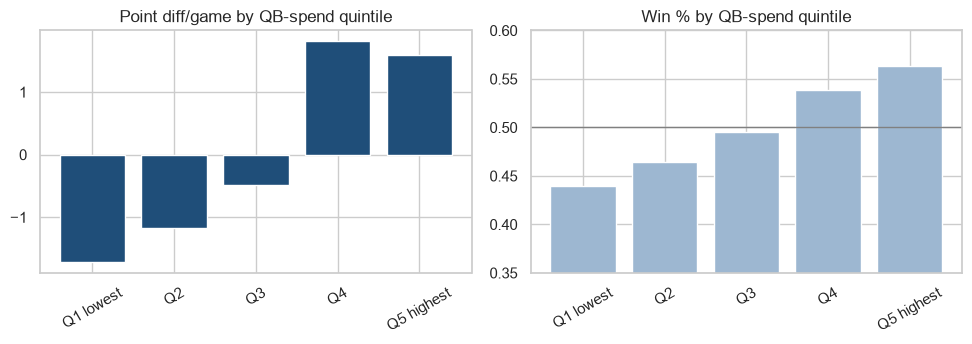

,avg_qb_starter_cap_m,qb_share_pct,win_pct,pt_diff_pg,n
qb_quintile,,,,,
Q1 lowest,1.576,1.005,0.440,-1.713,84
Q2,5.350,3.313,0.464,-1.176,83
Q3,9.290,5.766,0.495,-0.484,83
Q4,18.876,11.447,0.538,1.807,83
Q5 highest,26.326,16.506,0.564,1.598,83


In [6]:
ts["qb_quintile"] = pd.qcut(ts.QB_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
q = ts.groupby("qb_quintile", observed=True).agg(avg_qb_starter_cap_m=("QB_starter", "mean"), qb_share_pct=("QB_st", "mean"),
        win_pct=("win_pct", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(q.index, q.pt_diff_pg, color="#1f4e79"); ax[0].set(title="Point diff/game by QB-spend quintile")
ax[1].bar(q.index, q.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by QB-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); q.round(3)

In [7]:
# is it dollars at QB or just "good teams pay QBs"? try lagged spending (last year's QB share -> this year's results)
ts = ts.sort_values(["team", "season"])
ts["QB_st_lag"] = ts.groupby("team")["QB_st"].shift(1)
lag = fit("pt_diff_pg ~ QB_st_lag", ts.dropna(subset=["QB_st_lag"]))
same = fit("pt_diff_pg ~ QB_st")
print(f"same-season QB starter share: {same.params['QB_st']:.3f} pts/g per pt (p={same.pvalues['QB_st']:.3g})")
print(f"prior-season QB starter share: {lag.params['QB_st_lag']:.3f} pts/g per pt (p={lag.pvalues['QB_st_lag']:.3g})")

# the cheap-QB exception: rookie-deal QBs who played a lot
starters = ps[(ps.pos_group == "QB") & (ps.role == "starter")]
print("\nStarting QBs by cap hit tier (cap $M):")
print(starters.groupby(pd.cut(starters.cap_m, [0, 5, 15, 30, 100])).size())

same-season QB starter share: 0.234 pts/g per pt (p=3.55e-05)
prior-season QB starter share: 0.134 pts/g per pt (p=0.0242)

Starting QBs by cap hit tier (cap $M):
cap_m
(0, 5]       128
(5, 15]      138
(15, 30]     126
(30, 100]     24
dtype: int64


## 5. Deep dive: Wide receiver

WR spend does **not** show the QB pattern. The lowest-spending quintile (about 2.7% of cap) is worst (−1.4 pts/game), but from Q2 upward it is flat: roughly 0 to +0.8 with no trend, and the top quintile (about 14%) is at about 0. That looks like **diminishing returns after a modest level of WR investment**, not a payoff for stars.

Splitting WR spend into the top-paid WR vs. the other starters, neither is distinguishable from zero (top WR +0.04, others −0.03 per point of cap share, wide intervals). Bench WR spend is negative but not significant (−0.20, p=0.11). With 416 team-seasons, we can rule out large WR effects but not small ones.

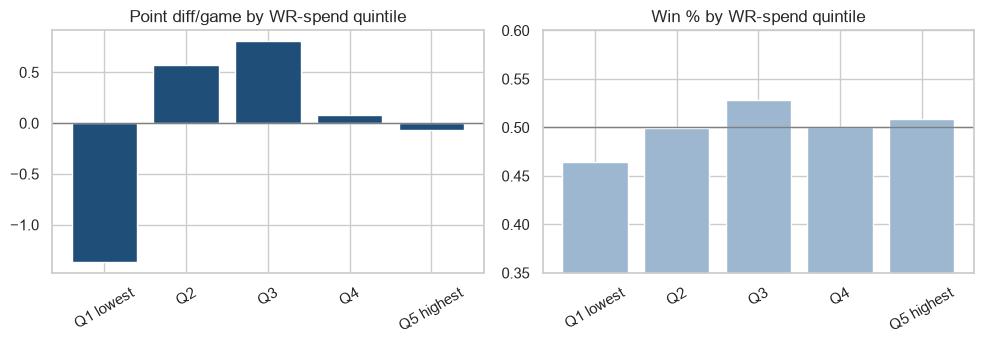

,wr_share_pct,win_pct,pt_diff_pg,n
wr_quintile,,,,
Q1 lowest,2.660,0.465,-1.365,84
Q2,4.979,0.499,0.574,83
Q3,7.218,0.528,0.803,83
Q4,10.015,0.501,0.083,83
Q5 highest,14.341,0.508,-0.067,83


In [8]:
ts["wr_quintile"] = pd.qcut(ts.WR_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
w = ts.groupby("wr_quintile", observed=True).agg(wr_share_pct=("WR_st", "mean"), win_pct=("win_pct", "mean"),
        pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(w.index, w.pt_diff_pg, color="#1f4e79"); ax[0].axhline(0, color="grey", lw=1); ax[0].set(title="Point diff/game by WR-spend quintile")
ax[1].bar(w.index, w.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by WR-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); w.round(3)

In [9]:
# does it matter HOW the WR money is split? top-paid WR vs. the other starting WRs
wr = ps[(ps.pos_group == "WR") & (ps.role == "starter")].copy()
wr["cap_rank"] = wr.groupby(["season", "team"])["cap_m"].rank(ascending=False, method="first")
wr["slot"] = np.where(wr.cap_rank == 1, "WR_top", "WR_other")
split = wr.pivot_table(index=["season", "team"], columns="slot", values="cap_m", aggfunc="sum", fill_value=0).reset_index()
d = ts.merge(split, on=["season", "team"])
d["WR_top_pct"] = d.WR_top / d.tracked_cap_m * 100; d["WR_other_pct"] = d.WR_other / d.tracked_cap_m * 100
m = fit("pt_diff_pg ~ WR_top_pct + WR_other_pct + WR_bn", d)
pd.DataFrame({"coef": m.params, "p": m.pvalues, "lo": m.conf_int()[0], "hi": m.conf_int()[1]}).loc[["WR_top_pct", "WR_other_pct", "WR_bn"]].round(3)

,coef,p,lo,hi
WR_top_pct,0.041,0.715,-0.180,0.263
WR_other_pct,-0.031,0.884,-0.444,0.383
WR_bn,-0.198,0.111,-0.441,0.045


## 6. Robustness

- **Win % as outcome (a):** same story. QB (p=0.005) and TE (p=0.03) are the only positions with significant starter coefficients.
- **Last season's spending (b):** QB (+0.12, p=0.046) and TE (+0.39, p=0.009) survive; everything else stays near zero. Using lagged spending reduces, but does not eliminate, the "good teams just spend more" concern.

In [10]:
# (a) win % as the outcome instead of point differential
rows = []
for p in POS:
    a = fit(f"win_pct ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef_winpct": a.params[f"{p}_st"], "p": a.pvalues[f"{p}_st"]})
pd.DataFrame(rows).set_index("pos").round(4)

,starter_coef_winpct,p
pos,,
QB,0.005,0.005
RB,0.002,0.755
WR,0.001,0.602
TE,0.011,0.030
OL,-0.000,0.965
DL,-0.001,0.646
EDGE,0.002,0.411
LB,-0.000,0.940
CB,-0.001,0.812


In [11]:
# (b) all positions with last season's spending (reduces "good teams spend more" reverse causality)
lagcols = []
for p in POS:
    ts[f"{p}_st_lag"] = ts.groupby("team")[f"{p}_st"].shift(1); lagcols.append(f"{p}_st_lag")
ts["ST_lag"] = ts.groupby("team")["ST_pct"].shift(1)
m_lag = fit("pt_diff_pg ~ " + " + ".join(lagcols) + " + ST_lag", ts.dropna(subset=lagcols))
pd.DataFrame({"coef": m_lag.params, "p": m_lag.pvalues}).loc[lagcols].round(3)

,coef,p
QB_st_lag,0.118,0.046
RB_st_lag,-0.117,0.508
WR_st_lag,-0.015,0.815
TE_st_lag,0.390,0.009
OL_st_lag,0.060,0.435
DL_st_lag,-0.069,0.361
EDGE_st_lag,0.035,0.729
LB_st_lag,-0.039,0.674
CB_st_lag,-0.078,0.482
S_st_lag,-0.006,0.964


## 7. Caveats & next steps

**Caveats**
- This is association, not causation. Teams choose spending, and strong teams may pay stars *because* they are strong.
- Cap hit is an accounting number (prorated bonuses, restructures), not the market price of a player's production.
- Tracked cap is only part of the official cap (dead money and some players are missing), so I use *shares* of tracked cap. Coverage differs by year.
- A traded player's cap is assigned to a single team. The starter label uses the team where he played the most snaps.
- 416 team-seasons is a small sample for 10 positions at once. TE in particular has a small share and a wide interval.
- Starters are defined *after the fact* by snaps. A star who is injured all year counts as bench. That is intended, but it means "bench" includes wasted cap.

**Next steps**
1. Control for rookie-contract QBs explicitly, for example with the draft round and years of experience from the `players` table.
2. Add EPA/play (offense, defense) as a second outcome, which is more direct than point differential.
3. Check how sensitive the results are to the starter definition (top-N slots vs. snap-share cutoffs).
4. Dig into TE and OL, the two surprises beyond QB.
5. Decide on a dashboard (position explorer by team and season).